<a href="https://colab.research.google.com/github/Innovatewithapple/NeuralNetwork/blob/main/NeuralNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------- Data --------------------
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).T   # shape (2,4)
d = np.array([[0, 1, 1, 0]])                       # shape (1,4)

# -------------------- Initialize --------------------
def initialize_network_parameters():
    inputSize = 2
    hiddenSize = 2
    outputSize = 1
    lr = 0.1
    epochs = 10000

    w1 = np.random.rand(hiddenSize, inputSize) * 2 - 1
    b1 = np.random.rand(hiddenSize, 1) * 2 - 1

    w2 = np.random.rand(outputSize, hiddenSize) * 2 - 1
    b2 = np.random.rand(outputSize, 1) * 2 - 1

    return w1, b1, w2, b2, lr, epochs

# -------------------- Sigmoid --------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# -------------------- Initialize params --------------------
w1, b1, w2, b2, lr, epochs = initialize_network_parameters()

# -------------------- Training --------------------
error_list = []

for epoch in range(epochs):

    # -------- Forward pass --------
    z1 = np.dot(w1, X) + b1
    a1 = sigmoid(z1)

    z2 = np.dot(w2, a1) + b2
    a2 = sigmoid(z2)

    # -------- Loss (for monitoring only) --------
    loss = -np.mean(d * np.log(a2 + 1e-8) + (1 - d) * np.log(1 - a2 + 1e-8))

    # -------- Backpropagation --------

    # Output layer (MODERN)
    dz2 = a2 - d
    dw2 = np.dot(dz2, a1.T)
    db2 = np.sum(dz2, axis=1, keepdims=True)

    # Hidden layer
    da1 = np.dot(w2.T, dz2)
    dz1 = da1 * (a1 * (1 - a1))
    dw1 = np.dot(dz1, X.T)
    db1 = np.sum(dz1, axis=1, keepdims=True)

    # -------- Update --------
    w2 -= lr * dw2
    b2 -= lr * db2

    w1 -= lr * dw1
    b1 -= lr * db1

    # -------- Logging --------
    if (epoch + 1) % 1000 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss:.5f}")
        error_list.append(loss)

# -------------------- Testing --------------------
z1 = np.dot(w1, X) + b1
a1 = sigmoid(z1)

z2 = np.dot(w2, a1) + b2
a2 = sigmoid(z2)

print("\nFinal Output:")
print(a2)

print("\nGround Truth:")
print(d)

# -------------------- Plot --------------------
plt.plot(error_list)
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
x_1 = 0.1
x_2 = 0.8
w_1 = 0.5
w_2 = 0.4
b_1 = 0.3

In [ ]:
z = x_1*w_1+x_2*w_2+b_1
z

0.67

In [ ]:
#Sigmoid
a_1 = 1/(1.0 + np.exp(-z))
a_1

np.float64(0.6615031592029524)

In [ ]:
# Another
weights = np.around(np.random.uniform(size=6),decimals=2)

bias = np.around(np.random.uniform(size=3),decimals=2)

In [ ]:
bias

array([0.67, 0.38, 0.51])

In [ ]:
weights

array([0.86, 0.26, 0.92, 0.16, 0.42, 0.58])

In [ ]:
x_1 = 0.5 # input 1
x_2 = 0.85 # input 2

In [ ]:
z_11 = x_1 * weights[0] + x_2 * weights[1] + bias[0]
print(z_11)

1.3210000000000002


In [ ]:
z_12 = x_1 * weights[2] + x_2 * weights[3] + bias[1]
print(z_12)

0.9760000000000001


In [ ]:
# Perform Sigmoid
a_11 = 1 / (1.0 + np.exp(-z_11))
print(a_11)

0.7893480323506185


In [ ]:
a_12 = 1 / (1.0 + np.exp(-z_12))
print(a_12)

0.7263138083016871


In [ ]:
z_21 = a_11 * weights[4] + a_12 * weights[5] + bias[2]
print(z_21)

1.2627881824022382


In [ ]:
a_21 = 1 / (1.0 + np.exp(-z_21))

In [ ]:
print(a_21)

0.7795057044282364


Activation function with loss function

In [ ]:
# Sigmoid-Activation
# 1/(1-e^-z)
zArr = [-1, 0, 1]
TArr = [0, 1, 1]   # targets

for z, T in zip(zArr, TArr):
    a = 1/(1+np.exp(-z))
    # Sigmoid-
    # Loss = -[T*log(a) + (1-T)*log(1-a)]
    loss = -(T*np.log(a) + (1-T)*np.log(1-a))

    print("z:", z, "a:", round(a,3), "Loss:", round(loss,3))

z: -1 a: 0.269 Loss: 0.313
z: 0 a: 0.5 Loss: 0.693
z: 1 a: 0.731 Loss: 0.313


In [ ]:
X = np.array([[0,0],[0,1],[1,0],[1,1]]).T
d = np.array([[0,1,1,0]])
X
d

array([[0, 1, 1, 0]])

In [ ]:
a = np.random.rand(2,3)
a

array([[0.6796921 , 0.07066318, 0.18716817],
       [0.80760564, 0.0913698 , 0.15863411]])

In [ ]:
def initialize_parameters(layers):
    weights = []
    biases = []
    lr = 0.1
    epochs = 180000

    for i in range(len(layers)-1):
        #print('i:',i)
        w = np.random.rand(layers[i+1], layers[i]) * 2 - 1
        b = np.random.rand(layers[i+1], 1) * 2 - 1
        #print('w:',w)
        weights.append(w)
        biases.append(b)

    return weights, biases, lr, epochs, layers[0],layers[-1]

layers = [2, 2, 2, 1]

weights, biases, lr, epochs, input, output = initialize_parameters(layers)
weights

[array([[ 0.5148, -0.0857],
        [-0.8593, -0.7676]]),
 array([[ 0.2935,  0.3611],
        [-0.3539, -0.0256]]),
 array([[-0.5635,  0.4814]])]

In [ ]:
print(weights[0].shape[1])

2


In [ ]:
biases

[array([[0.77472413],
        [0.4626323 ]]),
 array([[-0.63889085],
        [-0.24636693]]),
 array([[0.87416365]])]

In [ ]:
#Sigmoid function
def sigmoid(z):
  return 1/(1 + np.exp(-z))

In [ ]:
errorlist = []

for epoch in range(epochs):
  z1 = np.dot(weights[0],X) + biases[0]# from input to hidden layer
  a1 = sigmoid(z1) # Activation sigmoid of hidden layer first

  z2 = np.dot(weights[1],a1) + biases[1]# from hidden layer to another hidden layer
  a2 = sigmoid(z2) # Activation sigmoid of hidden layer

  z3 = np.dot(weights[2],a2) + biases[2] # from hidden layer to output
  a3 = sigmoid(z3)# Activation sigmoid of output layer
 # print('a2: ',a2)
  #lossa
  loss = -np.mean(d * np.log(a3 + 1e-8) + (1 - d) * np.log(1 - a3 + 1e-8))
 # print('loss: ',loss)

  #Backward propogation-Output layer:
  dz3 = a3 - d
  dw3 = np.dot(dz3,a2.T)
  db3 = np.sum(dz3,axis=1,keepdims=True)

  #Backward propogation-Hidden layer:
  da2 = np.dot(weights[2].T,dz3)
  dz2 = da2 * (a2 * (1 - a2))
  dw2 = np.dot(dz2, a1.T)
  db2 = np.sum(dz2,axis=1,keepdims=True)

  #Backward propogation-Hidden layer:
  da1 = np.dot(weights[1].T,dz2)
  dz1 = da1 * (a1 * (1 - a1))
  dw1 = np.dot(dz1,X.T)
  db1 = np.sum(dz1,axis=1,keepdims=True)
  # print('dzW2: ',dzW2)
  # print('dzB2: ',dzB2)

  # print('dzW1: ',dzW1)
  # print('dzB1: ',dzB1)

# update weight & bias
  weights[2] -= lr * dw3
  biases[2] -= lr * db3

  weights[1] -= lr * dw2
  biases[1] -= lr * db2

  weights[0] -= lr * dw1
  biases[0] -= lr * db1

# -------- Logging --------
  if (epoch + 1) % 10000 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss:.5f}")
        print("mean |dz1|:", np.mean(np.abs(dz1)))
        errorlist.append(loss)

      #   ❌ BAD VANISHING EXAMPLE (LIKE YOUR LOG)
      #  Epoch 1000, Loss: 0.69
      #  mean |dz1|: 1.2e-05

      #  Epoch 5000, Loss: 0.69
      #  mean |dz1|: 9.8e-06

      #  Epoch 10000, Loss: 0.69
      #  mean |dz1|: 8.5e-06


Epoch 10000, Loss: 0.00075
mean |dz1|: 1.9418196840077782e-07
Epoch 20000, Loss: 0.00038
mean |dz1|: 1.0612563828051946e-07
Epoch 30000, Loss: 0.00025
mean |dz1|: 7.428459445796921e-08
Epoch 40000, Loss: 0.00019
mean |dz1|: 5.75964585828334e-08
Epoch 50000, Loss: 0.00015
mean |dz1|: 4.724636858947391e-08
Epoch 60000, Loss: 0.00013
mean |dz1|: 4.0168337910183374e-08
Epoch 70000, Loss: 0.00011
mean |dz1|: 3.5007242089589995e-08
Epoch 80000, Loss: 0.00009
mean |dz1|: 3.106890353121686e-08
Epoch 90000, Loss: 0.00008
mean |dz1|: 2.7959894348974583e-08
Epoch 100000, Loss: 0.00008
mean |dz1|: 2.544012135114215e-08
Epoch 110000, Loss: 0.00007
mean |dz1|: 2.3354531383712035e-08
Epoch 120000, Loss: 0.00006
mean |dz1|: 2.1598402667723036e-08
Epoch 130000, Loss: 0.00006
mean |dz1|: 2.009838711374329e-08
Epoch 140000, Loss: 0.00005
mean |dz1|: 1.8801539265340516e-08
Epoch 150000, Loss: 0.00005
mean |dz1|: 1.766865825598025e-08
Epoch 160000, Loss: 0.00005
mean |dz1|: 1.667008326378349e-08
Epoch 1700

In [ ]:
np.set_printoptions(suppress=True, precision=4)

In [ ]:
z1 = np.dot(weights[0],X) + biases[0]
a1 = sigmoid(z1)

z2 = np.dot(weights[1],a1) + biases[1]
a2 = sigmoid(z2)

print("\nFinal Output:")
print(a2)

print("\nGround Truth:")
print(d)


Final Output:
[[0.0002 0.9999 0.9999 0.0001]
 [0.0002 0.9999 0.9999 0.0001]]

Ground Truth:
[[0 1 1 0]]


In [ ]:
# Step 1: Prediction
pred = (a2 > 0.5).astype(int)

# Step 2: Accuracy
accuracy = np.mean(pred == d)

# Step 3: Print everything
print("Probabilities:", a2)
print("Predictions:", pred)
print("Actual:", d)
print("Accuracy:", accuracy * 100, "%")
print("Errors per sample:", pred - d)

Probabilities: [[0.0002 0.9999 0.9999 0.0001]
 [0.0002 0.9999 0.9999 0.0001]]
Predictions: [[0 1 1 0]
 [0 1 1 0]]
Actual: [[0 1 1 0]]
Accuracy: 100.0 %
Errors per sample: [[0 0 0 0]
 [0 0 0 0]]


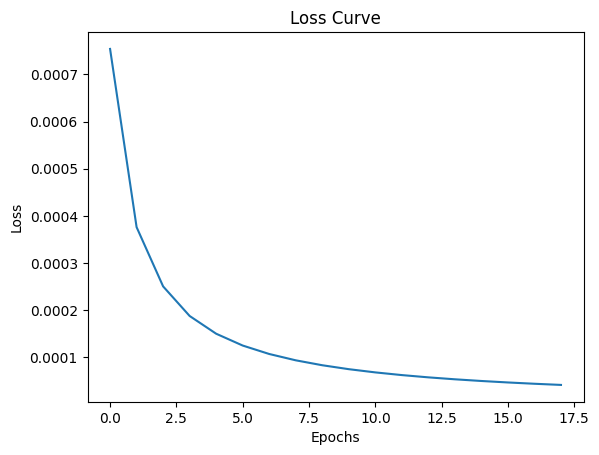

In [ ]:
plt.plot(errorlist)
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()